<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/TWOYEAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Prueba de hipótesis lineal de dos estimadores iguales $\;H_0:\;\beta_i=\beta_{i+1}$**

<br>

Con los datos **twoyear.raw** que corresponden al estudio de [Kane y Rouse (1995)](https://www.jstor.org/stable/2118190?seq=1), vamos a realizar la regresión

$$\widehat{lwage}=\beta_0  +\beta_1 jc  +\beta_2 univ +\beta_3 exper+u,\qquad(\clubsuit)$$

con las variables explicativas:

* *jc:* años de asistencia en college (creditos de 2 años),

* *univ:* años de asistencia en universidad (creditos de 4 años),

* *exper:* experiencia laboral (meses).


Los datos muestran que puede haber cualquier combinación entre *jc* y *univ*. Nos interesa mostrar que <mark>un año más de estudio en *college* tiene el mismo impacto en el salario, que un año más de estudio en la *universidad*; es decir, tienen el mismo incremento porcentual.</mark> Esto lo planteamos con la siguiente hipótesis nula

$$H_0:\;\beta_1=\beta_2.\qquad(\heartsuit)$$

La hipótesis alternativa de interés es una prueba de una cola, asumiendo que un año más en la universidad tiene un mayor impacto en el salario que un año más en carrera corta (*college*), de modo que

$$H_1:\;\beta_1<\beta_2.\qquad(2\heartsuit).$$

Las hipótesis $(\heartsuit)$ y $(2\heartsuit)$ las podemos reescribir introduciendo el parámetro $\theta_1=\beta_1-\beta_2$, de modo que planteamos las siguientes hipótesis


$$H_0:\;\theta_1=0.\qquad(♥)$$

y la alternativa

$$H_1:\;\theta_1 < 0.\qquad(2♥).$$

Las hipótesis $(♥)$ tienen la ventaja de que nos permite calcular el error estandar del parámetro de interés $\theta_1$. En wooldridge (2019) sec. 4.4, explica la dificultad que conlleva utilizar la hipótesis $(\heartsuit)$, basicamente nos muestra que es muy complicado calcular el error estandar $ee(\hat\beta_1-\hat\beta_2)$. Observemos que

$$\theta_1=\beta_1-\beta_2\quad\Rightarrow \quad \beta_1=\theta_1+\beta_2,$$
por lo tanto, es necesario definir una nueva variable

$$\widetilde{totuniv}=jc+univ,$$
que denota el total de años de universidad. Ahora escribimos la regresión


$$\widehat{lwage}=\beta_0  +\theta_1 jc  +\beta_2 \widetilde{totuniv} +\beta_3 exper+u,\qquad(\spadesuit).$$



Observa que

$$\begin{align}
\theta_1 jc  +\beta_2 \widetilde{totuniv}
&= (\beta_1-\beta_2)jc  +\beta_2 (jc+univ)\\
&= \beta_1 jc\;-\beta_2jc+\beta_2 jc\;+\beta_2univ\\
&= \beta_1 jc+\beta_2univ.
\end{align}$$
Esto muestra que la ecuación $(\spadesuit)$, matemáticamente equivale a la ecuación $(\clubsuit)$; sin embargo, por como  hemos definido a $theta_1$, este estimador nos proporcionara el error estandar que buscamos, es decir $ee(\theta)=ee(\hat\beta_1-\hat\beta_2)$. Por lo tanto, la prueba de hipótesis $(♥)$ la realizamos con la ecuación


$$t=\frac{\hat\theta_1}{ee(\theta)}.$$


<br>

---

Comenzamos instalando el paquete ```wooldridge``` en Colab.

In [ ]:
!pip install wooldridge

In [ ]:
import wooldridge as woo
import numpy as np
import statsmodels.formula.api as smf
import scipy.stats as sts

twoyear = woo.dataWoo('twoyear')
twoyear

,female,phsrank,BA,AA,black,hispanic,id,exper,jc,univ,...,medcity,submed,lgcity,sublg,vlgcity,subvlg,ne,nc,south,totcoll
0,1,65,0,0,0,0,19.0,161,0.000000,0.000000,...,0,0,0,1,0,0,1,0,0,0.000000
1,1,97,0,0,0,0,93.0,119,0.000000,7.033333,...,0,0,0,0,0,0,0,1,0,7.033333
2,1,44,0,0,0,0,96.0,81,0.000000,0.000000,...,0,0,0,1,0,0,1,0,0,0.000000
3,1,34,0,0,0,1,119.0,39,0.266667,0.000000,...,0,0,0,0,0,0,0,0,0,0.266667
4,1,80,0,0,0,0,132.0,141,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6758,1,50,0,0,0,0,89903.0,62,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0.000000
6759,1,50,0,0,0,0,89908.0,111,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0.000000
6760,0,50,0,0,0,0,89933.0,146,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0.000000
6761,0,50,0,0,0,0,89955.0,125,0.000000,0.000000,...,0,0,0,0,0,0,0,0,1,0.000000


## **Regresión $(\clubsuit)$**



In [ ]:
# regresion OLS:
reg_1 = smf.ols(formula='lwage ~ jc+univ+exper',data=twoyear).fit()
reg_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     644.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:26:02   Log-Likelihood:                -3888.7
No. Observations:                6763   AIC:                             7785.
Df Residuals:                    6759   BIC:                             7813.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4723      0.021     69.910      0.000       1.431       1.514
jc             0.0667      0.007      9.767      0.000       0.053       0.080
univ           0.0769      0.002     33.298      0.000       0.072       0.081
exper          0.0049      0.000     31.397      0.000       0.005       0.005
==============================================================================
Omnibus:                       81.514   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.465
Skew:                          -0.036   Prob(JB):                     1.16e-31
Kurtosis:                       3.707   Cond. No.                         512.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Interpretación de la regresión**

Las variables son significativas estadísitcamente y el impacto de *jc*<*univ*. Sin embargo, para establecer que es así, vamos a probar la hipótesis $(\spadesuit)$.

## **Agregamos una variable a la base de datos.**


En la ecuación $(\spadesuit)$ agregamos la variable $\widetilde{totuniv}=jc+univ$ (la base de datos original ya la tiene definida); sin embargo, para otros ejemplos es importante aprender a definir variables en python y es de la siguiente manera.

In [ ]:
twoyear['totcoll2']=twoyear.jc+twoyear.univ


## **Regresión $(\spadesuit)$**



In [ ]:
# regresion OLS:
reg_2 = smf.ols(formula='lwage ~ jc+totcoll2+exper',data=twoyear).fit()
reg_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  lwage   R-squared:                       0.222
Model:                            OLS   Adj. R-squared:                  0.222
Method:                 Least Squares   F-statistic:                     644.5
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:26:02   Log-Likelihood:                -3888.7
No. Observations:                6763   AIC:                             7785.
Df Residuals:                    6759   BIC:                             7813.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4723      0.021     69.910      0.000       1.431       1.514
jc            -0.0102      0.007     -1.468      0.142      -0.024       0.003
totcoll2       0.0769      0.002     33.298      0.000       0.072       0.081
exper          0.0049      0.000     31.397      0.000       0.005       0.005
==============================================================================
Omnibus:                       81.514   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              142.465
Skew:                          -0.036   Prob(JB):                     1.16e-31
Kurtosis:                       3.707   Cond. No.                         511.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **Prueba de hipótesis del estadístico $\theta_1$.**

La regresión $(\spadesuit)$ básicamente la hicimos para encontrar $ee(\theta)$ y con el error estandar calculamos el estad´stico-$t$ del estimador $\theta_1$, que esta definido por
$$\widehat{t}=\frac{\hat\theta_1}{ee(\theta)}.$$

Como la hipótesis alternativa es de una cola (izquierda) $\theta_1< 0$, debemos tener claro el sentido de la desigualdad. En este caso el criterio es

$$\text{Si}\;\widehat{t}\;<\;crit-t\quad\Rightarrow\quad H_0:\theta=0\;\text{¡se rechaza!},$$
donde $crit-t$ es el valor crítico correspondiente al nivel de significancia $\alpha$ con $gl$ grados de libertad $(n-k-1)$.

También podemos comparar el p-value de $\widehat{t}$ que se obtiene con `st.t.cdf($\hat{t}$,gl)`.

$$\text{Si}\;p-value(\widehat{t})\;<\;\alpha\quad\Rightarrow\quad H_0:\theta=0\;\text{¡se rechaza!},$$


In [ ]:
import scipy.stats as st

#   nivel de significancia
alpha=.05
gl=6759

crit_v=st.t.ppf(alpha,gl)

print(f'nivel de significancia (alpha)={alpha:.2f}')

tTheta0=-0.0102/0.0068

#   Dado que tTheta0<0, se invierte la desigualdad
if tTheta0 < crit_v:
    print(f'Dado que t-value={tTheta0:.4f}< crit-value={crit_v:.4f},\n se rechaza H0.')
else:
    print(f'Dado que t-value={tTheta0:.4f}> crit-value={crit_v:.4f},\n NO se rechaza H0.')


p_Theta0=st.t.cdf(tTheta0,gl)
print(f'p-val del estadistico Theta0={p_Theta0:.3f}')


nivel de significancia (alpha)=0.05
Dado que t-value=-1.5000> crit-value=-1.6451,
 NO se rechaza H0.
p-val del estadistico Theta0=0.067


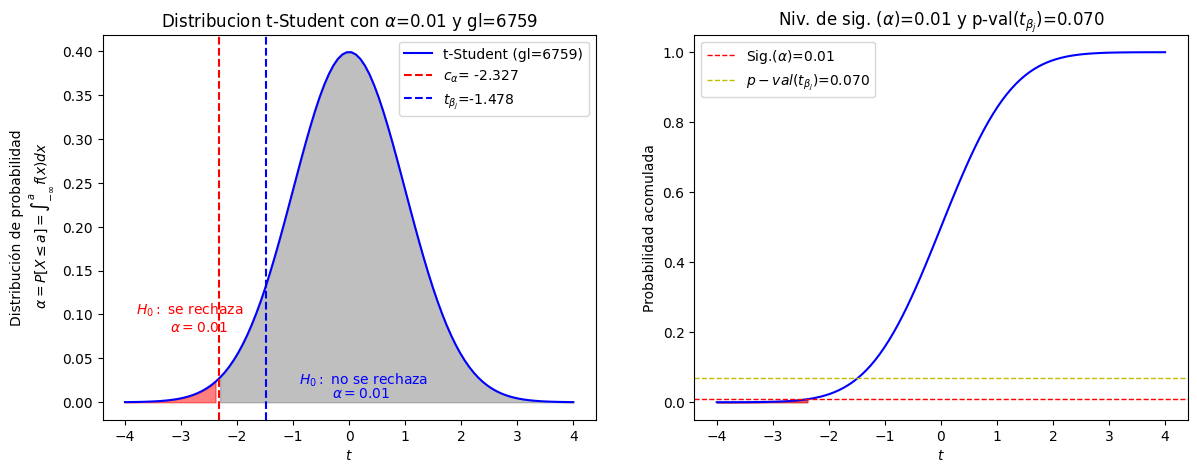

In [ ]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

#   nivel de significancia
alpha=.01

#   gl lo hemos definido con   '.df_resid' /or/ agregalo manual
gl=6759

#      t-critico correspondiente a los gl de OLS
t_cr=st.t.ppf(alpha, gl)

#     t-value//estadistico-t_{\beta_j} del estimador $\beta_j$
#     Estos son los t-values que presenta .summary()
tBj=-0.0102/0.0069
p_tBj=st.t.cdf(tBj,gl)
p_vBj=(p_tBj)

#               Inicia la gráfica
x=np.linspace(-4, 4, 100)
tcurve=st.t.pdf(x, gl)
CDFcurve=st.t.cdf(x, gl)

# Graficando las distribuciones #
plt.figure(figsize = (14,5))
#############################################################
#                            (a)
#############################################################
plt.subplot(1,2,1)
#   Gráfica de curva PDF

plt.plot(x,tcurve, label=f't-Student (gl={gl})', color='blue')

# Shade the critical regions
plt.fill_between(x,tcurve, where=x<t_cr, color='r', alpha=0.5)
plt.fill_between(x,tcurve, where=x>t_cr, color='gray', alpha=0.5)

# Vertical lines for critical values
plt.axvline(t_cr, linestyle='dashed', color='r', label=rf'$c_\alpha$= {t_cr:.3f}')
#  estadistico-t
plt.axvline(tBj, linestyle='dashed', color='b', label=r'$t_{\beta_j}$=' f'{tBj:.3f}')

#     texto H0
plt.text(-.9,.02, r'$H_0:$ no se rechaza',c='b',fontsize=10)
plt.text(-.3,.005, r'$\alpha=$' f'{alpha:.2f}',c='b',fontsize=10)
plt.text(-3.8,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)
plt.text(-3.2,.08, r'$\alpha=$' f'{alpha:.2f}',c='r',fontsize=10)

plt.xlabel(r'$t$')
plt.ylabel('Distribución de probabilidad\n '
            r'$\alpha=P[X\leq a]=\int_{-\infty}^af(x)dx$')
plt.title(r'Distribucion t-Student con $\alpha$=' f'{alpha} y gl={gl}')
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(x,CDFcurve,color='blue')  # label=f't-Student (gl={gl})'

#   Rango de rechazo de H_0
plt.fill_between(x,CDFcurve, where=x<=t_cr,color='gray',alpha=.5)


#    p-value evaluacion
plt.fill_between(x,CDFcurve, where=(CDFcurve<(1-alpha))&(x<t_cr),color='red',alpha=.5)
plt.axhline((alpha),color='r',linewidth=1,linestyle='dashed',label=r'Sig.$(\alpha)$='f'{(alpha):.2f}')
plt.axhline(p_vBj,color="y",linewidth=1,linestyle="dashed", label=r'$p-val(t_{\beta_j})$='f'{p_vBj:.3f}')

plt.xlabel(r'$t$')
plt.ylabel('Probabilidad acomulada')
plt.title(r'Niv. de sig. $(\alpha)$=' f'{alpha:.2f}'  r' y p-val($t_{\beta_j}$)='f'{p_vBj:.3f}')
plt.legend()

plt.savefig('curvaPDF-CDF.jpg', dpi=300, bbox_inches='tight')


plt.show()

# **Prueba F de Fisher (anova)**

La prueba de Fisher que se estudio en el **analisis de varianza** (anova), se puede generalizar para probar la similitud de estimadores de OLS.


<br>


## **Hipótesis múltiple**


$$H_0:\;\beta_1=\beta_2.$$


La hipótesis alternativa  es

$$H_1:\;¡H_0\;\text{NO es verdadera!}.$$


## **Estadísico-F en python**

Más tarde veremos la generalidad de la prueba de Fisher, por el momento solo pretendo mostrar que lo anterior lo podemos hacer simple utilizando la prueba de Fisher al resultado de la primer regresión lineal, utilizando el la función de python `model.f_test("beta1 = beta2") `.

#### **Interpretación del resultado:**

Si el $p-value < \alpha$, entonces se rechaza la $H_0$ y se concluye que <mark>$\beta_1$
y $\beta_2$ son significativamente diferentes.</mark>


In [ ]:
F_test01=reg_1.f_test("jc = univ")

Fpval1=F_test01.pvalue
Ffval1=F_test01.fvalue
nu1=F_test01.df_num
nu2=F_test01.df_denom

print(f'Estadístico-F ={Ffval1:.3f}')
print(f'Estadístico-F p-value={Fpval1:.3f}')
print(f'gl num. ={nu1:.0f}')
print(f'gl den. ={nu2:.0f}')


alpha=0.1
#   Criterio de prueba del estadístico-F
if Fpval1 < alpha:
    print(f'Dado que p-value={Fpval1:.3f}< niv. de sig.={alpha:.3f} ¡se rechaza H0!,',
    '\n  de modo que beta1 y beta2 son significativamente diferentes')
else:
    print(f'Dado que p-value={Fpval1:.3f}> niv. de sig.={alpha:.3f} ¡NO se rechaza H0!,',
    '\n  de modo que beta1 y beta2 son significativamente iguales')

#F_test01


Estadístico-F =2.154
Estadístico-F p-value=0.142
gl num. =1
gl den. =6759
Dado que p-value=0.142> niv. de sig.=0.100 ¡NO se rechaza H0!, 
  de modo que beta1 y beta2 son significativamente iguales


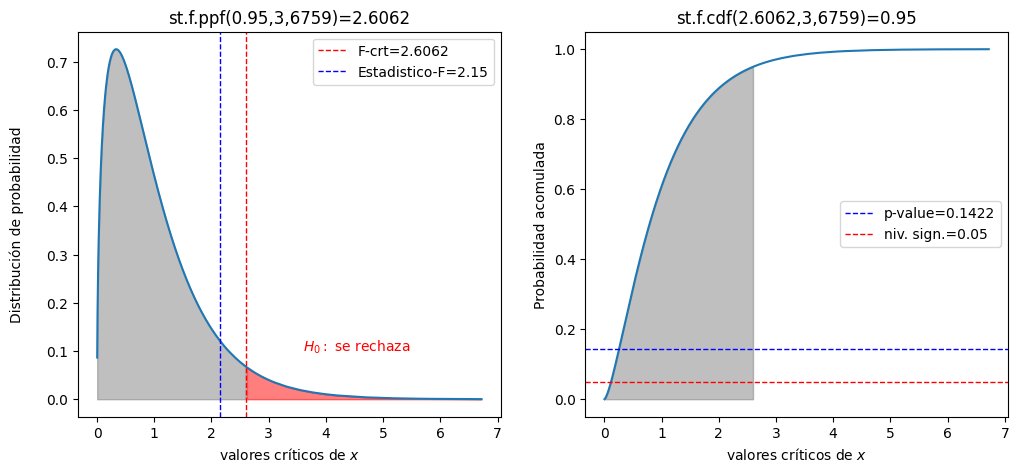

In [ ]:
# @title
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

##   Grados de libertad
gl1=3
gl2=nu2
##   Nivel de significancia alpha  en la Distribución-F
alpha=0.95
signif=1-alpha
F_crt=st.f.ppf(alpha,gl1,gl2)

#   Muestras
muestra1=np.random.chisquare(gl1, size=1000)
muestra2=np.random.chisquare(gl2, size=1000)

#   Estadistico-F: calculamos el estadistico-F
f_value=(muestra1/gl1)/(muestra2/gl2)
#   Ordenamos (sort) el estadistico-F para graficar
f_value=np.sort(f_value)

#   crea la curva normal
curvaPDF=st.f.pdf(f_value,gl1,gl2)
curvaCDF=st.f.cdf(f_value,gl1,gl2)


# Graficando las distribuciones #
plt.figure(figsize = (12,5))
#############################################################
#                            (a)
#############################################################

#     definimos un valor supremo en x (para la grafica)
#xsup=9

plt.subplot(1,2,1)
#   Gráfica de curva PDF
plt.plot(f_value,curvaPDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaPDF, where=f_value<F_crt,color='gray',alpha=.5)
plt.fill_between(f_value,curvaPDF, where=f_value>F_crt,color='red',alpha=.5)

#     texto H0
plt.text(F_crt+1,.1, r'$H_0:$ se rechaza',c='r',fontsize=10)

plt.axvline(F_crt, color = "r", linewidth = 1, linestyle = "dashed",label=f'F-crt={F_crt:.4f}')
plt.axvline(Ffval1, color = "b", linewidth = 1, linestyle = "dashed",label=f'Estadistico-F={Ffval1:.2f}')

plt.title(f'st.f.ppf({alpha:.2f},{gl1:.0f},{gl2:.0f})={F_crt:.4f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Distribución de probabilidad\n ')
#plt.xlim(0,xsup)
plt.legend()

plt.savefig('curvaPDF.jpg', dpi=300, bbox_inches='tight')

#############################################################
#                            (b)
#############################################################
plt.subplot(1,2,2)
#   Gráfica de la curva CDF
plt.plot(f_value,curvaCDF)
#   Rango de rechazo de H_0
plt.fill_between(f_value,curvaCDF, where=f_value<F_crt,color='gray',alpha=.5)
plt.axhline(Fpval1, color = "b", linewidth = 1, linestyle = "dashed",label=f'p-value={Fpval1:.4f}');
plt.axhline(signif, color = "r", linewidth = 1, linestyle = "dashed",label=f'niv. sign.={signif:.2f}');

plt.title(f'st.f.cdf({F_crt:.4f},{gl1:.0f},{gl2:.0f})={alpha:.2f}',fontsize=12)
plt.xlabel('valores críticos de $x$')
plt.ylabel('Probabilidad acomulada')
#plt.xlim(0,xsup)
plt.savefig('curvaCDF.jpg', dpi=300, bbox_inches='tight')
plt.legend()

plt.show()


## **Resultados del modelo no restringido y modelo restringido**

In [ ]:
from statsmodels.iolib.summary2 import summary_col

print(summary_col([reg_1,reg_2],stars=True,float_format='%0.3f',
                  model_names=['Regresion 1', 'Regresion 2'],
                  info_dict={'N':lambda x: "{0:d}".format(int(x.nobs)),
                             'R2':lambda x: "{:.2f}".format(x.rsquared)}))




               Regresion 1 Regresion 2
--------------------------------------
Intercept      1.472***    1.472***   
               (0.021)     (0.021)    
jc             0.067***    -0.010     
               (0.007)     (0.007)    
univ           0.077***               
               (0.002)                
exper          0.005***    0.005***   
               (0.000)     (0.000)    
totcoll2                   0.077***   
                           (0.002)    
R-squared      0.222       0.222      
R-squared Adj. 0.222       0.222      
N              6763        6763       
R2             0.22        0.22       
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


# **Conclusión:**

.